In [ ]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [2]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

In [27]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


In [ ]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [5]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [6]:
burst_times = all_bursts['waveform_times'] * 1000 

In [8]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

In [9]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [10]:
def reject_outliers(X, m=3):
    """
    https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')
    mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    return [d for d in X if lower_bound <= d <= upper_bound]


def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad, method='standard'):
    if np.any(mad == 0):
        raise ValueError("MAD is zero for at least one feature, cannot scale data.")

    if method == 'robust':
        return 0.67449 * np.abs(X - median) / mad
    elif method == 'standard':
        return (X - median) / mad

In [11]:
area = c_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    # scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx])                       # .fit() returns the median and IQR values
    # scaler = StandardScaler().fit(all_bursts['waveform'][subj_idx])                     # .fit() returns the mean and std values
    # scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])  # .transform() does the maths.
    
    median, mad = scaler_fit(all_bursts['waveform'][subj_idx & area])
    scaled_waveforms[subj_idx, :] = scaler_transform(all_bursts['waveform'][subj_idx], median, mad)

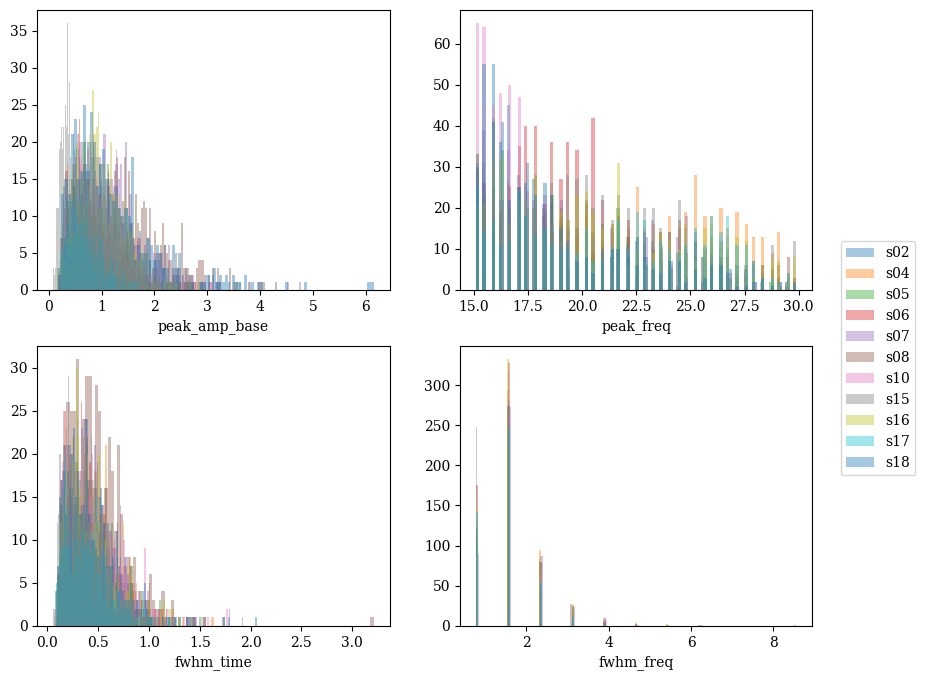

In [100]:
time_freq_feats = ['peak_amp_base', 'peak_freq', 'fwhm_time', 'fwhm_freq']
labels = []
n_bins = 4
feat_bin_lims = np.zeros((len(time_freq_feats), n_bins + 1))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for feat_idx, feat in enumerate(time_freq_feats):
    ax = axes[feat_idx]
    for subject in subjects:
        subj_idx = (all_bursts['subject']==subject) & area
        feat_count = all_bursts[feat][subj_idx]

        if subject not in labels:
            labels.append(subject)

        ax.hist(feat_count, bins=100, label=subject, alpha=0.4)
        ax.set_xlabel(feat)

        # feat_bin_lims[feat_idx, :] = np.percentile(all_bursts[feat][subj_idx], np.linspace(0, 100, n_bins + 1))
        # for bin_idx in range(len(feat_bin_lims[feat_idx, :]) - 1):
        #     count = len(np.where((all_bursts[feat_count][time_freq_feats[feat_idx]] >= feat_bin_lims[feat_idx][bin_idx]) &
        #                         (all_bursts[feat_count][time_freq_feats[feat_idx]] < feat_bin_lims[feat_idx][bin_idx+1]))[0])
        #     print(count)
        
        # ax.vlines(feat_bin_lims[feat_idx])

        if feat_idx == [0 or 2]:
            ax.set_ylabel("Counts")

fig.legend(labels, bbox_to_anchor=(1.01, 0.6))

In [ ]:
# Subject-level cross-validation: split subjects into train/test groups

n_splits = 10           # Number of folds for cross-validation
n_bins = 4              # Number of bins to use for each gcPC
time_freq_feats = ['peak_amp_base', 'peak_freq', 'fwhm_time', 'fwhm_freq']

subjects_score = []
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject) & area
    trials = np.unique(all_bursts['trial'][subj_idx])

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)
    
    fold_score = []
    for fold_idx, (train_index, test_index) in enumerate(kf.split(trials)):
        train_bursts_idx = np.isin(all_bursts['trial'], trials[train_index]) & subj_idx
        train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')
            
        # GCPCA model trained only on test set bursts of the current subject
        gcpca_model = gcPCA(method='v4', normalize_flag=False)                                                      # gcPCA model creation
        gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])        # gcPCA application on OFF/ON cortex
        
        # Project all bursts of the current subject into PC space using the trained model
        all_scores = scaled_waveforms@gcpca_model.loadings_
        
        X = []
        y = []
        pc_bin_lims = np.zeros((len(cols), n_bins + 1))
        # Build trial-level feature matrix X and matching label vector y
        for trial in trials:
            # For each trial, count how many bursts fall into each bin for the current gcPC
            burst_idx = subj_idx & (all_bursts["trial"]==trial)
            label = np.unique(all_bursts["med"][burst_idx])[0]

            row = []
            for i, col in enumerate(cols):
                # Compute percentile edges for each gcPC of interest across all bursts 
                pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

                for idx in range(len(pc_bin_lims[i, :]) - 1):
                    # Count bursts whose gcPC score falls within the current percentile bin
                    count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) &
                                        (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
                    row.append(count)

            X.append(row)
            y.append(0 if label=='OFF' else 1)

        X = np.array(X)
        y = np.array(y)

        model = LOR()
        model = model.fit(X[train_index, :], y[train_index])
        y_pred = model.predict(X[test_index, :])

        score = 1 - np.sqrt(np.mean((y[test_index] - y_pred) ** 2))
        print(f'Subject {subject} fold {fold_idx}: Score = {score:.3f}')
        fold_score.append(score)

    print(f'Subject {subject}: Mean Score = {np.mean(fold_score):.3f} ± {np.std(fold_score):.3f}')
    subjects_score.append(np.mean(fold_score))

print(f'Overall Mean Score across subjects: {np.mean(subjects_score):.3f} ± {np.std(subjects_score):.3f}')